In [1]:
import pandas as pd
import numpy as np



In [3]:
# Load dataset (adjust path if you download it locally)
url = "/kaggle/input/parkinson-disease-detection/Parkinsson disease.csv"
df = pd.read_csv("park.csv")

# Basic shape and first rows
print("Shape:", df.shape)
df.head()

Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [7]:
# Count missing values per column
missing_counts = df.isna().sum()

print("Missing values per column:")
print(missing_counts)

print("\nTotal missing values in the dataset:", missing_counts.sum())

Missing values per column:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

Total missing values in the dataset: 0


In [8]:

num_duplicates = df.duplicated().sum()
print("Number of duplicated rows:", num_duplicates)

# Optionally inspect duplicated rows (if any)
if num_duplicates > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)))

Number of duplicated rows: 0


In [9]:
from scipy import stats
import numpy as np
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Compute absolute z-scores
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Mark outliers where |z| > 3
z_outlier_mask = (z_scores > 3)

# Count outliers per column
z_outliers_per_column = z_outlier_mask.sum(axis=0)

print("Z-score Outliers per Column (|z| > 3):\n")
for col, count in zip(numeric_cols, z_outliers_per_column):
    print(f"{col}: {count}")

# Number of rows with any z-score outlier
z_outlier_rows = z_outlier_mask.any(axis=1).sum()
print("\nRows with at least one z-score outlier:", z_outlier_rows)


Z-score Outliers per Column (|z| > 3):

MDVP:Fo(Hz): 0
MDVP:Fhi(Hz): 7
MDVP:Flo(Hz): 0
MDVP:Jitter(%): 4
MDVP:Jitter(Abs): 5
MDVP:RAP: 4
MDVP:PPQ: 4
Jitter:DDP: 4
MDVP:Shimmer: 4
MDVP:Shimmer(dB): 4
Shimmer:APQ3: 3
Shimmer:APQ5: 3
MDVP:APQ: 3
Shimmer:DDA: 3
NHR: 5
HNR: 1
status: 0
RPDE: 0
DFA: 0
spread1: 0
spread2: 0
D2: 1
PPE: 1

Rows with at least one z-score outlier: 14


In [10]:
iqr_outliers_per_column = []
iqr_outlier_mask_df = pd.DataFrame(False, index=df.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Outlier mask for this feature
    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    iqr_outlier_mask_df[col] = mask
    
    iqr_outliers_per_column.append(mask.sum())

print("IQR Outliers per Column (Q1 - 1.5·IQR, Q3 + 1.5·IQR):\n")
for col, count in zip(numeric_cols, iqr_outliers_per_column):
    print(f"{col}: {count}")

# Number of rows containing at least one IQR outlier
iqr_outlier_rows = iqr_outlier_mask_df.any(axis=1).sum()
print("\nRows with at least one IQR outlier:", iqr_outlier_rows)



IQR Outliers per Column (Q1 - 1.5·IQR, Q3 + 1.5·IQR):

MDVP:Fo(Hz): 0
MDVP:Fhi(Hz): 11
MDVP:Flo(Hz): 9
MDVP:Jitter(%): 14
MDVP:Jitter(Abs): 7
MDVP:RAP: 14
MDVP:PPQ: 15
Jitter:DDP: 14
MDVP:Shimmer: 8
MDVP:Shimmer(dB): 10
Shimmer:APQ3: 6
Shimmer:APQ5: 13
MDVP:APQ: 12
Shimmer:DDA: 6
NHR: 19
HNR: 3
status: 48
RPDE: 0
DFA: 0
spread1: 4
spread2: 2
D2: 1
PPE: 5

Rows with at least one IQR outlier: 81


In [11]:
import pandas as pd
import numpy as np

# Separate numeric and categorical variables
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = ["name"]  # only 'name' is categorical

# Descriptive statistics for numeric variables
numeric_stats = df[numeric_cols].describe().T


numeric_stats

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


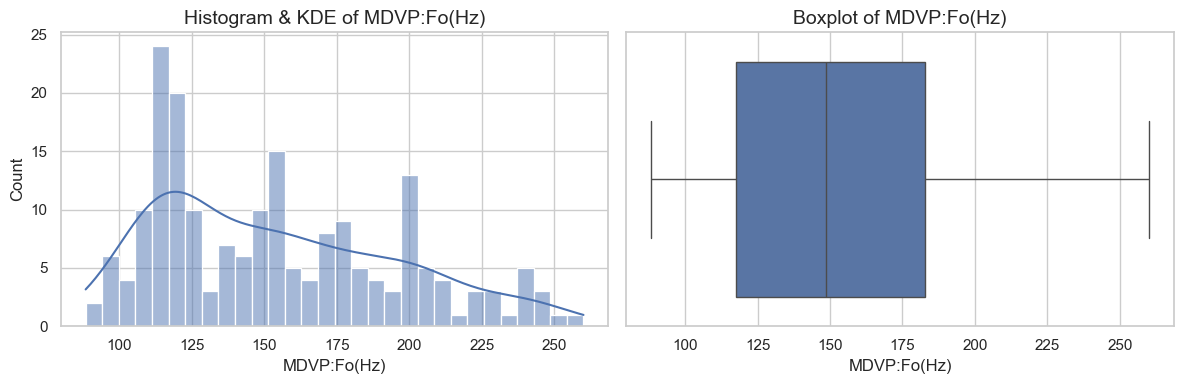

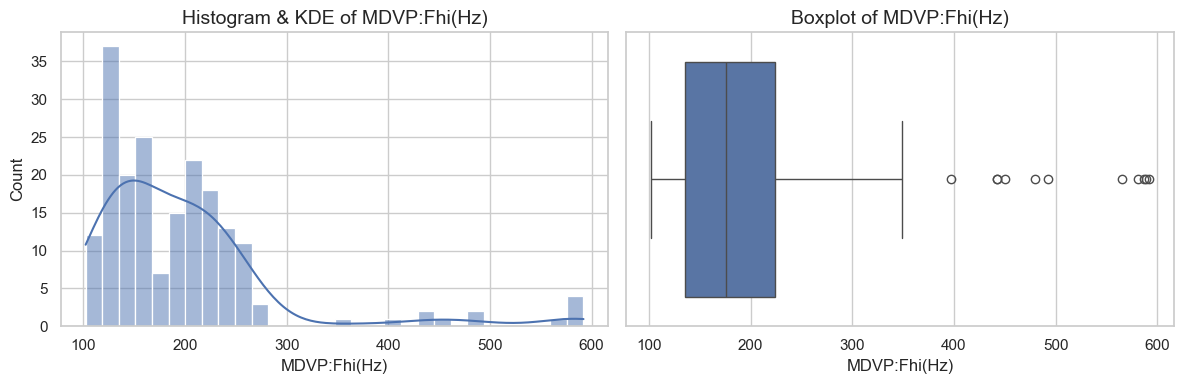

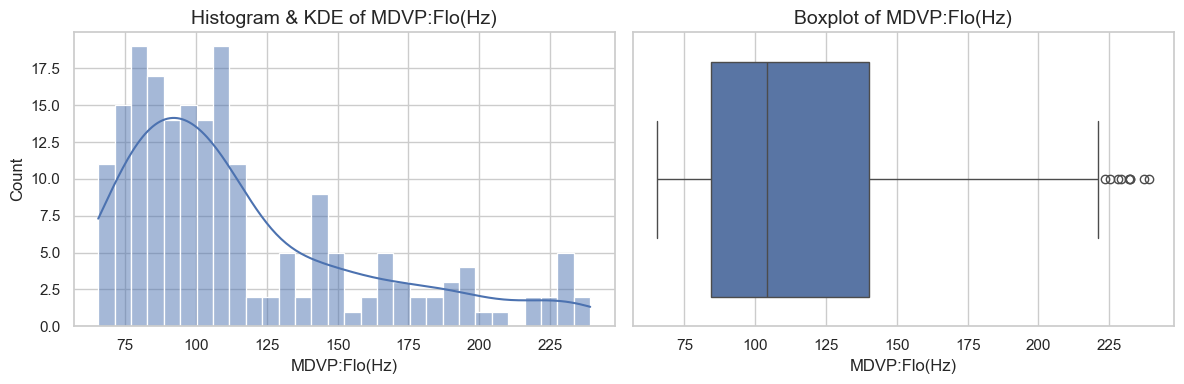

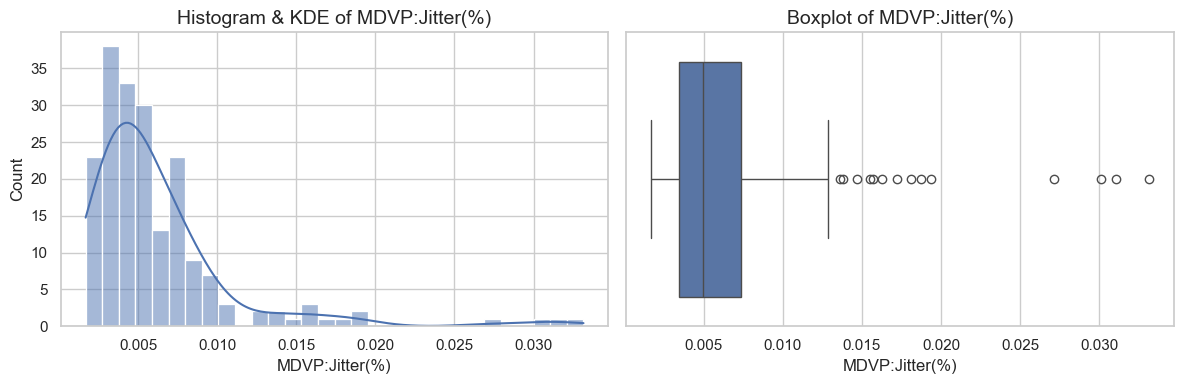

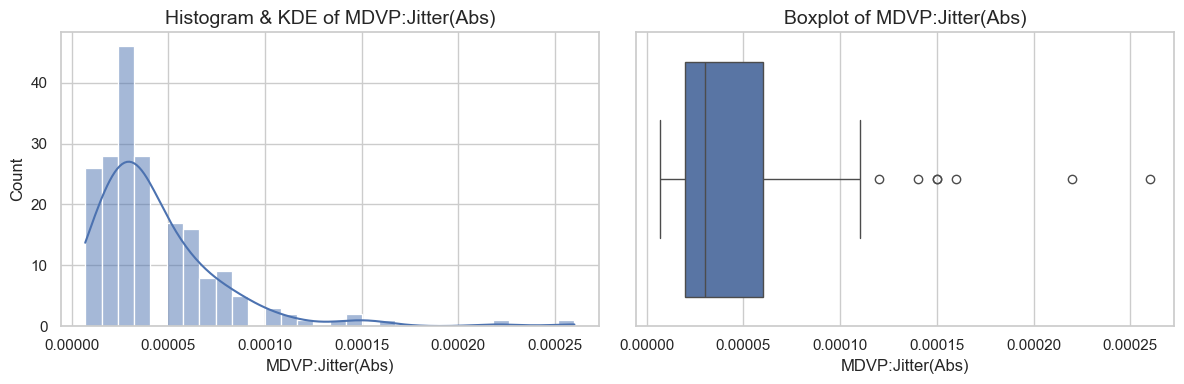

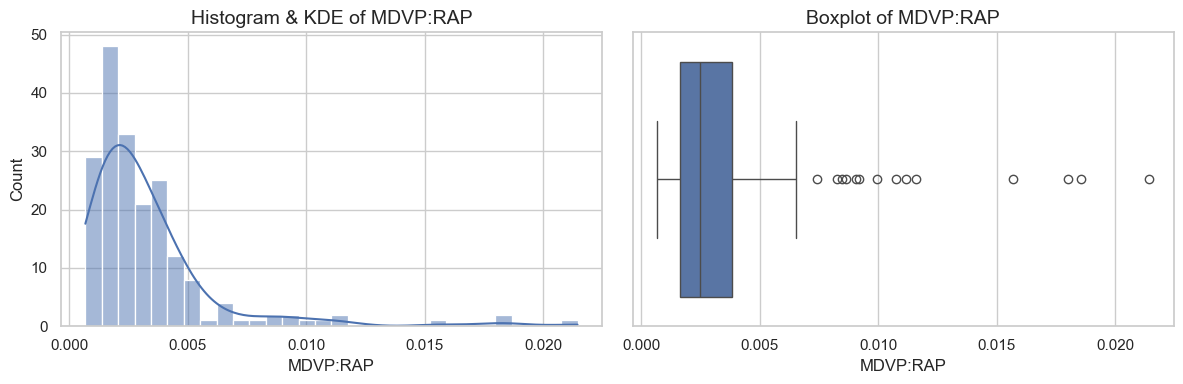

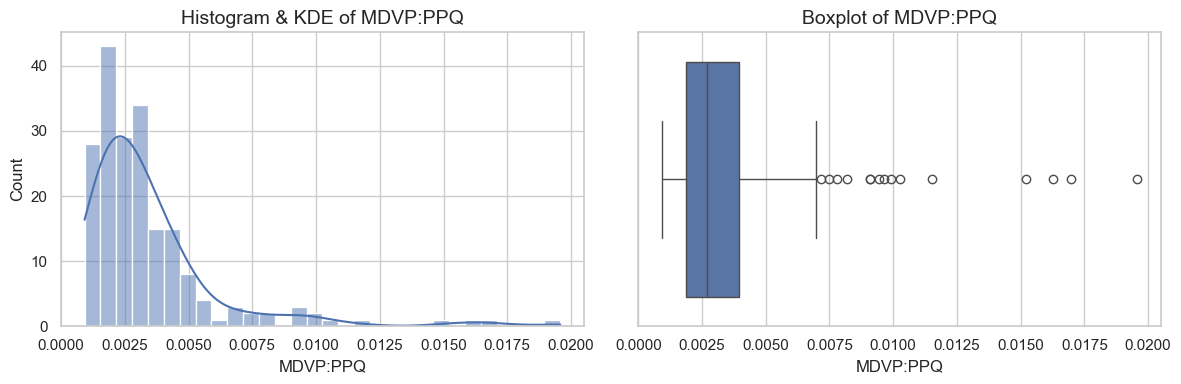

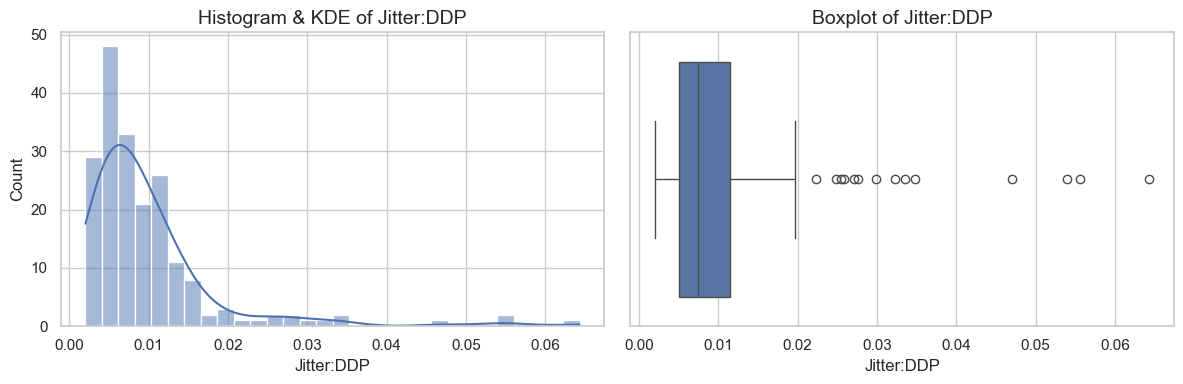

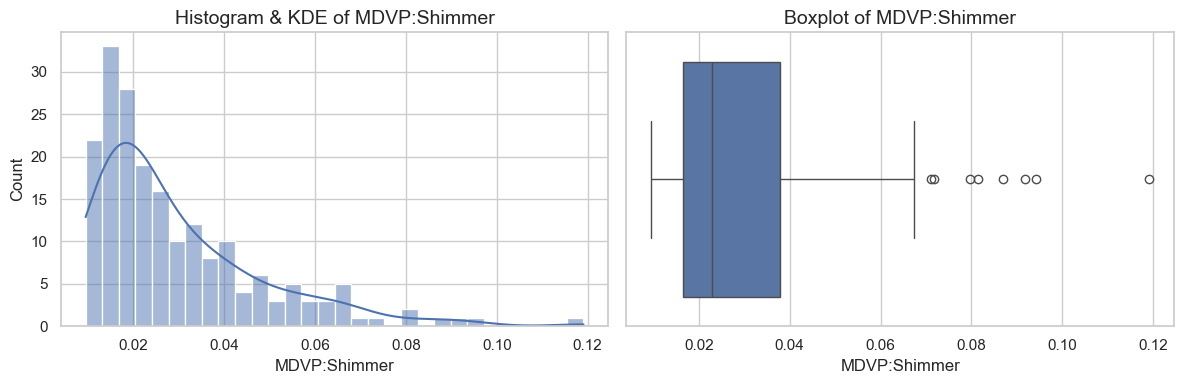

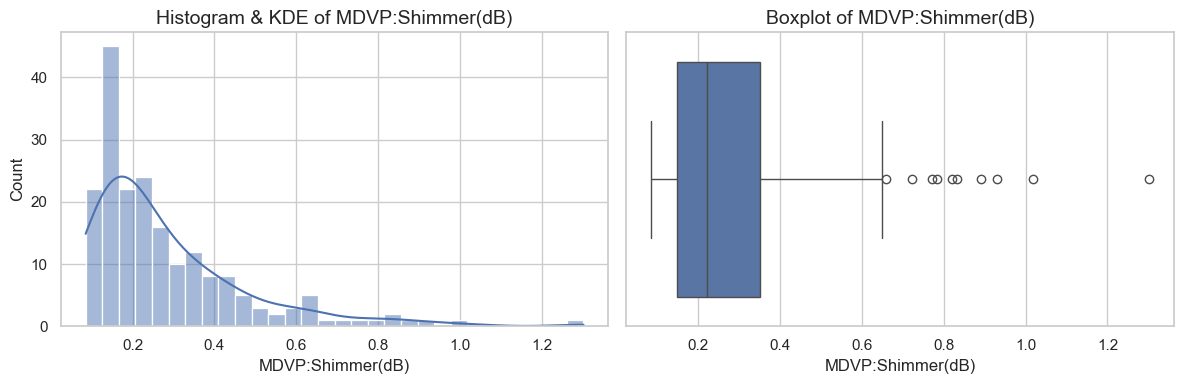

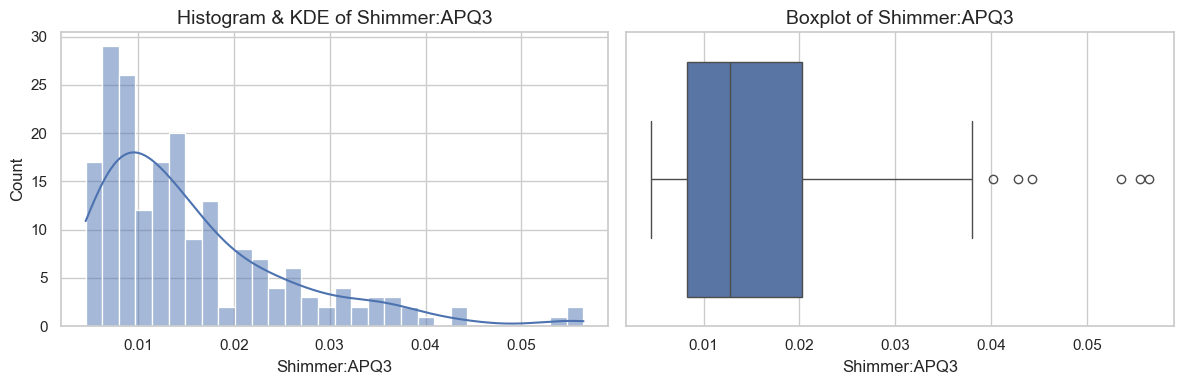

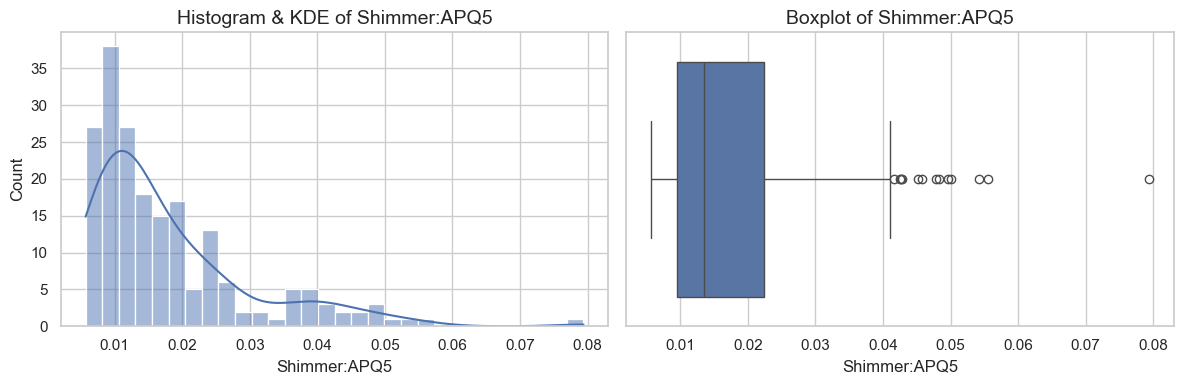

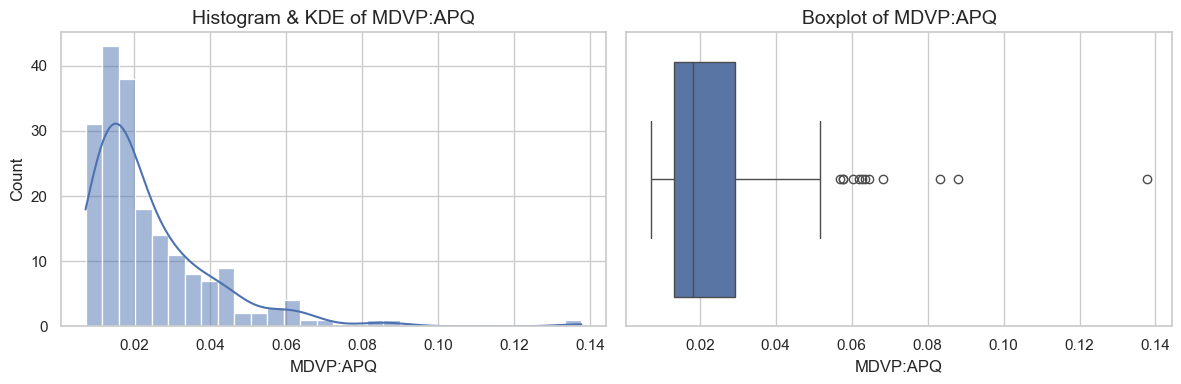

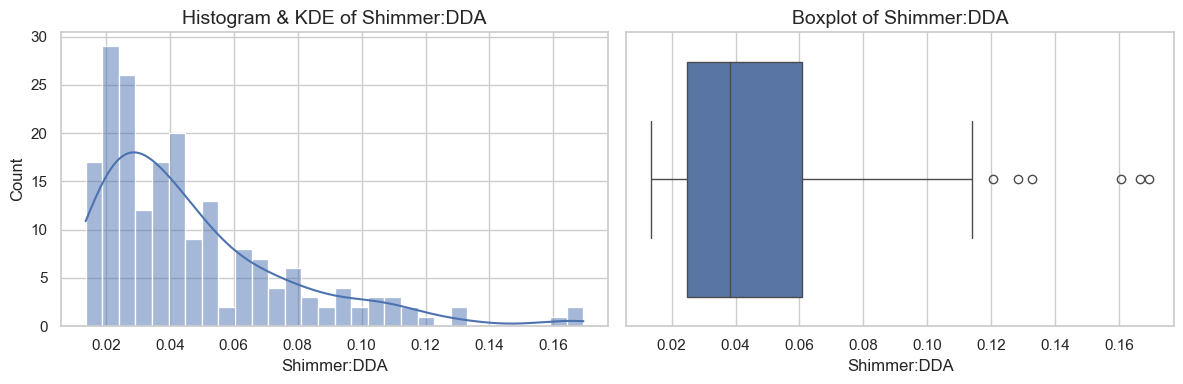

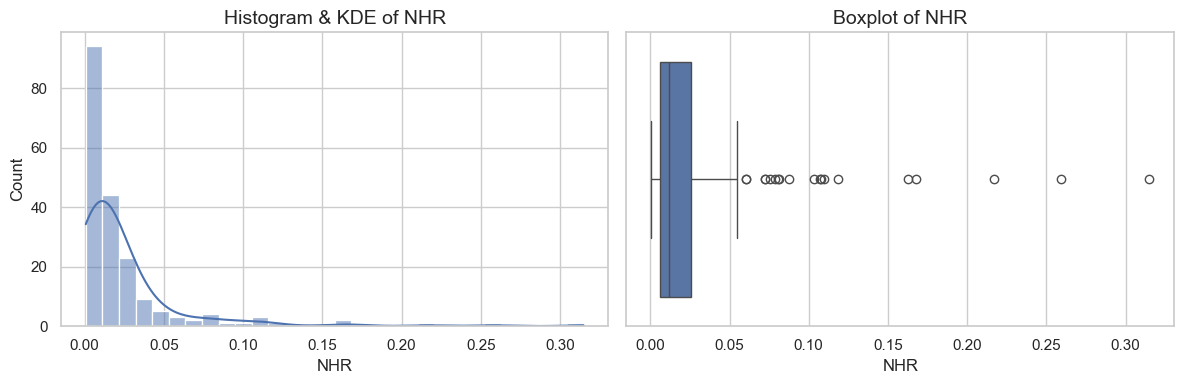

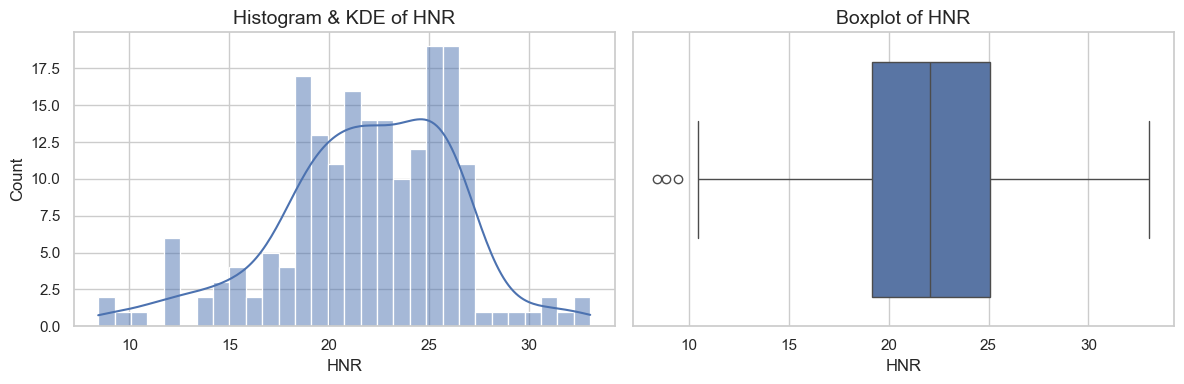

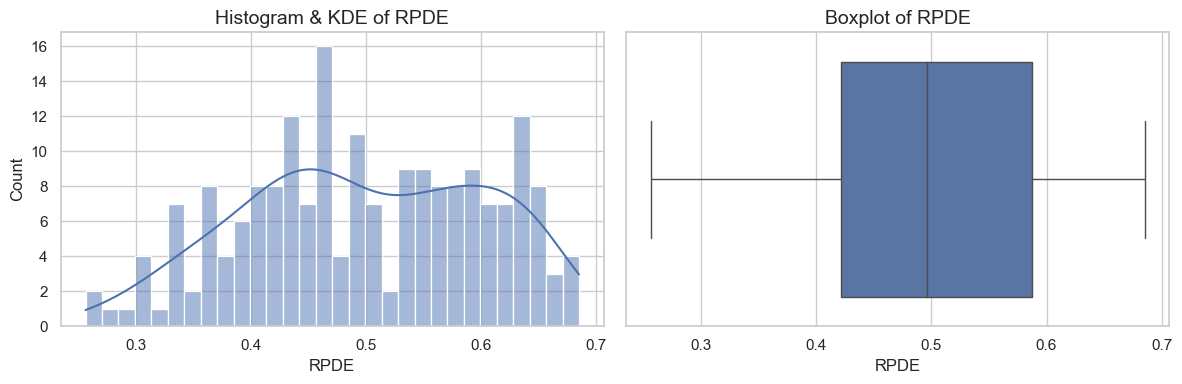

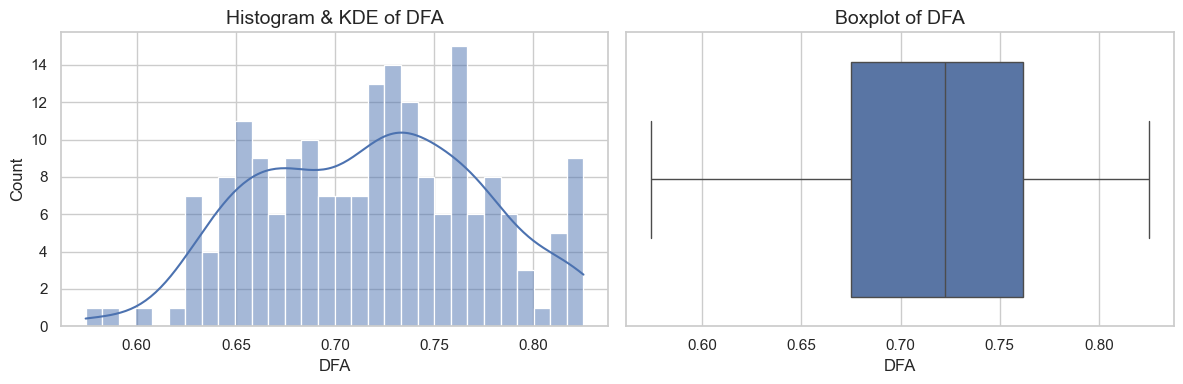

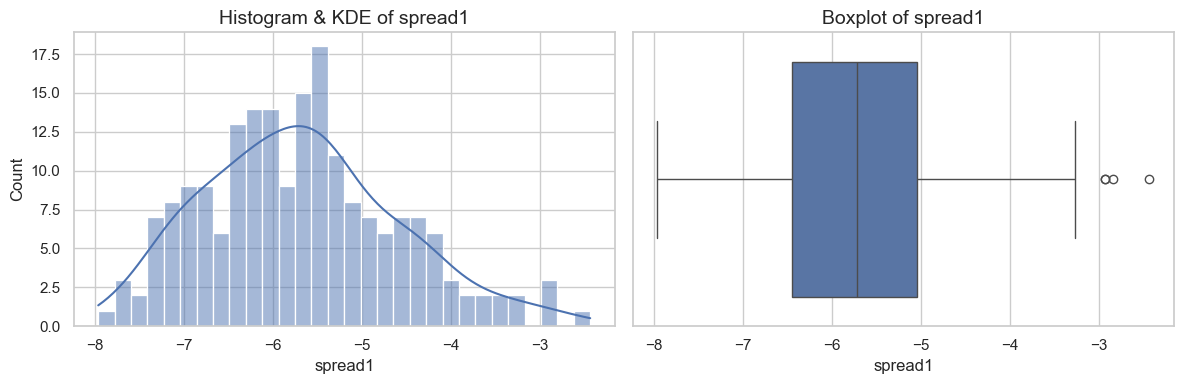

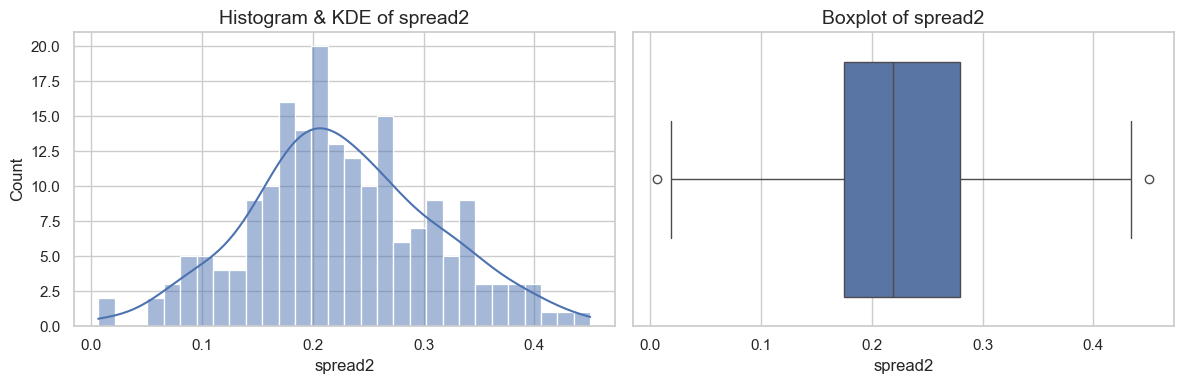

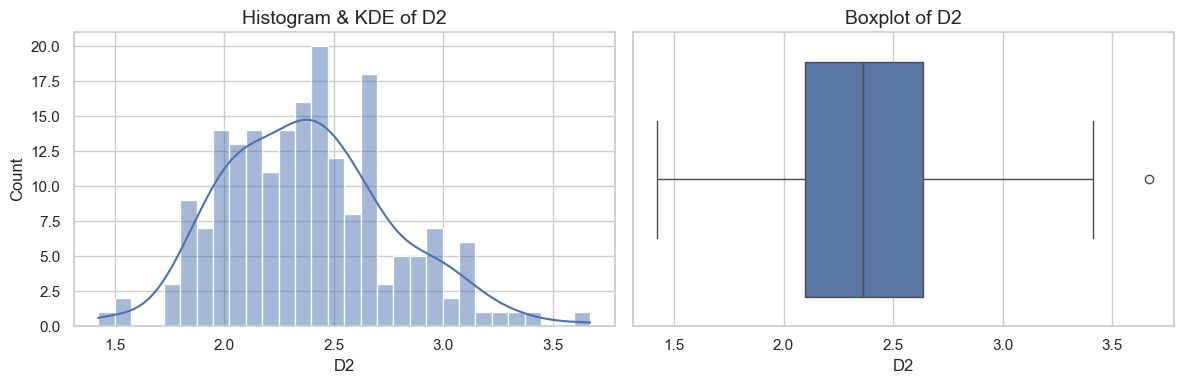

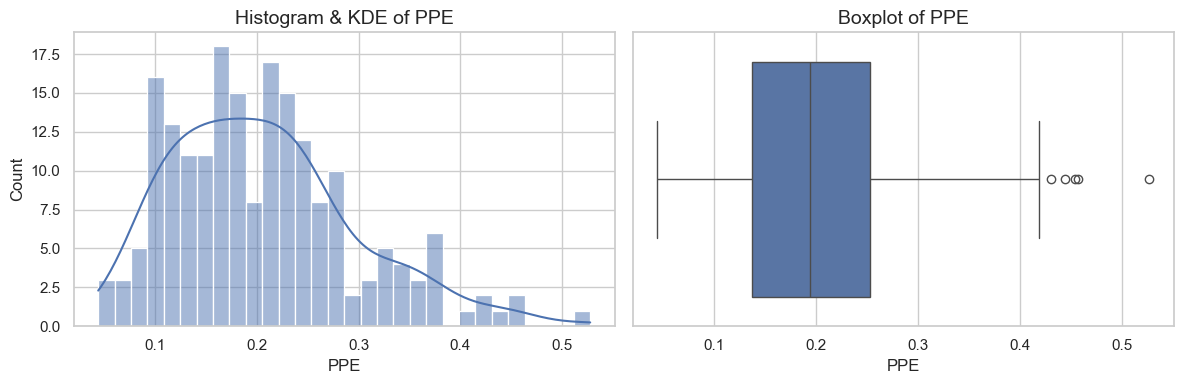

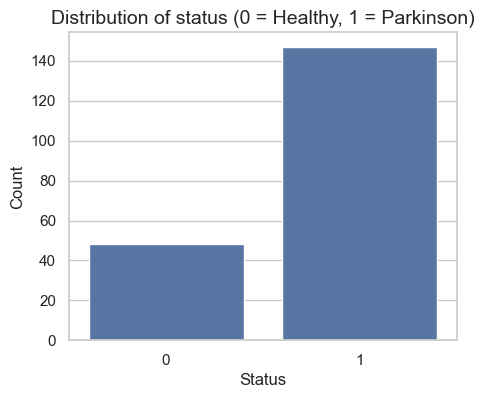

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# numeric columns except status (binary)
plot_numeric = [col for col in numeric_cols if col != "status"]

for col in plot_numeric:
    plt.figure(figsize=(12,4))
    
    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram & KDE of {col}", fontsize=14)
    plt.xlabel(col)

   # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], orient="h")
    plt.title(f"Boxplot of {col}", fontsize=14)
    
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x=df["status"])
plt.title("Distribution of status (0 = Healthy, 1 = Parkinson)", fontsize=14)
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [
    "MDVP:Fo(Hz)", "MDVP:Fhi(Hz)", "MDVP:Flo(Hz)",
    "MDVP:Jitter(%)", "MDVP:Jitter(Abs)", "MDVP:RAP", "MDVP:PPQ", "Jitter:DDP",
    "MDVP:Shimmer", "MDVP:Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5",
    "MDVP:APQ", "Shimmer:DDA",
    "NHR","HNR",
    "RPDE", "DFA", "spread1", "spread2", "D2", "PPE"
]


plt.figure(figsize=(16,12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

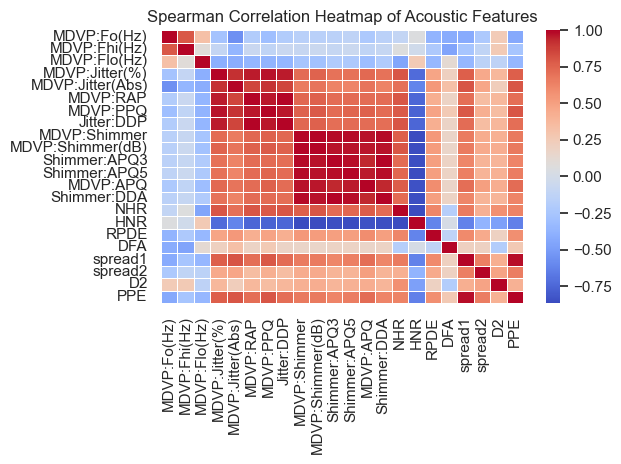

In [14]:
corr = df[feature_cols].corr(method="spearman")

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap of Acoustic Features")
plt.tight_layout()
plt.show()


In [16]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
import pandas as pd
import numpy as np

results = []

numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col != "status"]

for col in feature_cols:
    x0 = df[df["status"] == 0][col]
    x1 = df[df["status"] == 1][col]
    
    # Normality test
    p_norm_0 = shapiro(x0)[1]
    p_norm_1 = shapiro(x1)[1]
    
    normal_0 = p_norm_0 > 0.05
    normal_1 = p_norm_1 > 0.05
    
    # Levene test (equal variances)
    p_levene = levene(x0, x1)[1]
    equal_var = p_levene > 0.05
    
    # Choose statistical test
    if normal_0 and normal_1:                      # both normal
        if equal_var:
            test_used = "Student t-test"
            stat, p_value = ttest_ind(x0, x1, equal_var=True)
        else:
            test_used = "Welch t-test"
            stat, p_value = ttest_ind(x0, x1, equal_var=False)
    else:
        test_used = "Mann–Whitney U test"
        stat, p_value = mannwhitneyu(x0, x1, alternative="two-sided")
    
    results.append({"feature": col,
        "normal_group0_p": p_norm_0,
        "normal_group1_p": p_norm_1,
        "both_normal": normal_0 and normal_1,
        "levene_p": p_levene,
        "equal_variances": equal_var,
        "test_used": test_used,
        "test_statistic": stat,
        "p_value": p_value,
        "median_healthy": x0.median(),
        "median_PD": x1.median()
    })

test_table = pd.DataFrame(results)
test_table

,feature,normal_group0_p,normal_group1_p,both_normal,levene_p,equal_variances,test_used,test_statistic,p_value,median_healthy,median_PD
0,MDVP:Fo(Hz),1.710214e-05,3.506514e-04,False,9.499659e-07,False,Mann–Whitney U test,4944.000000,3.051504e-05,198.996000,145.174000
1,MDVP:Fhi(Hz),8.228954e-08,1.662601e-16,False,4.907375e-01,True,Mann–Whitney U test,4762.000000,2.796270e-04,231.161500,163.335000
2,MDVP:Flo(Hz),5.222788e-06,4.044446e-08,False,1.328482e-06,False,Mann–Whitney U test,4920.000000,4.151321e-05,113.938500,99.770000
3,MDVP:Jitter(%),3.117443e-07,4.352378e-16,False,1.088658e-02,False,Mann–Whitney U test,1568.500000,7.897927e-09,0.003355,0.005440
4,MDVP:Jitter(Abs),3.003215e-06,6.023380e-14,False,1.099281e-02,False,Mann–Whitney U test,1489.000000,1.275739e-09,0.000025,0.000040
5,MDVP:RAP,9.986587e-08,9.253262e-17,False,5.174109e-03,False,Mann–Whitney U test,1574.000000,8.689370e-09,0.001625,0.002840
6,MDVP:PPQ,1.770953e-06,7.178390e-16,False,3.116325e-03,False,Mann–Whitney U test,1501.500000,2.401494e-09,0.001775,0.003140
7,Jitter:DDP,1.014088e-07,9.145676e-17,False,5.194147e-03,False,Mann–Whitney U test,1570.500000,8.180063e-09,0.004875,0.008530
8,MDVP:Shimmer,3.516657e-04,2.606962e-09,False,3.499528e-07,False,Mann–Whitney U test,1533.000000,4.224740e-09,0.016705,0.028380
9,MDVP:Shimmer(dB),1.121275e-04,4.797812e-11,False,6.078164e-06,False,Mann–Whitney U test,1516.500000,3.143455e-09,0.154000,0.263000


/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/1159848612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


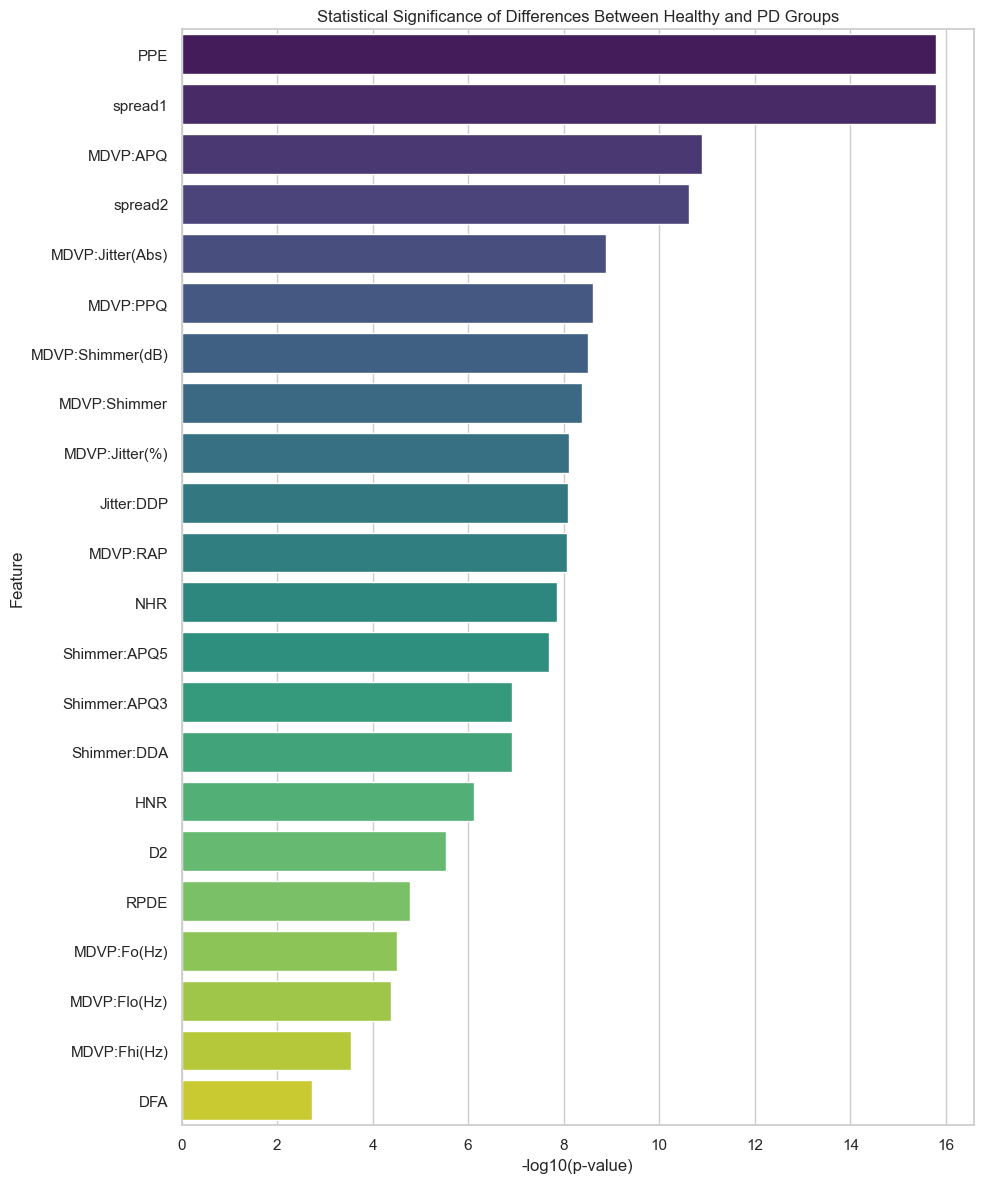

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))

# Sort by p-value ascending
plot_df = test_table.sort_values("p_value")

sns.barplot(
    x = -np.log10(plot_df["p_value"]), 
    y = plot_df["feature"],
    palette="viridis"
)

plt.xlabel("-log10(p-value)")
plt.ylabel("Feature")
plt.title("Statistical Significance of Differences Between Healthy and PD Groups")
plt.tight_layout()
plt.show()


/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


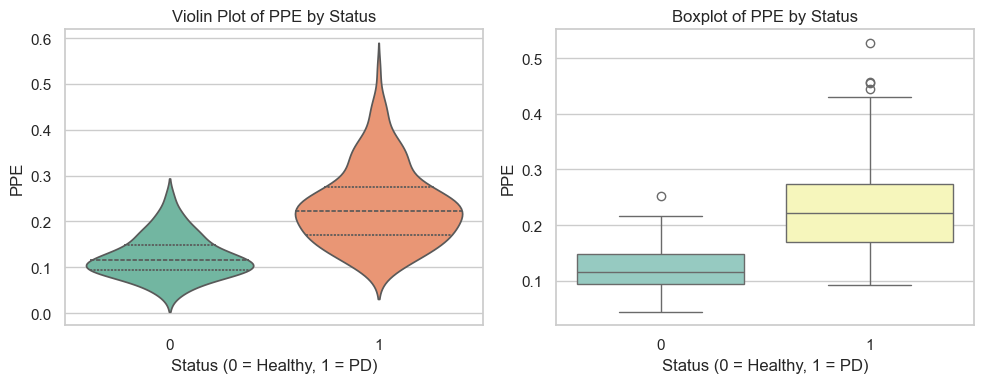

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


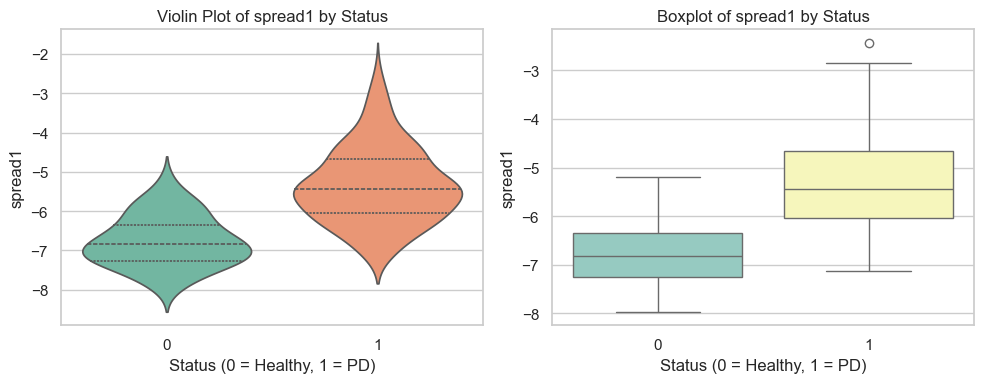

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


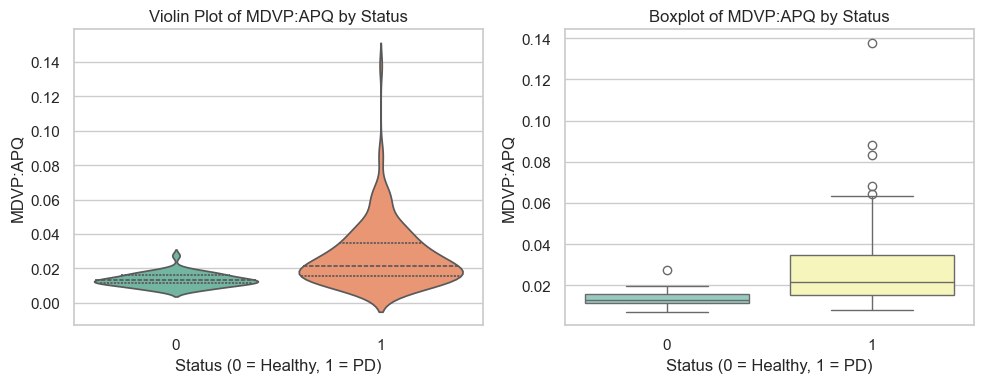

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


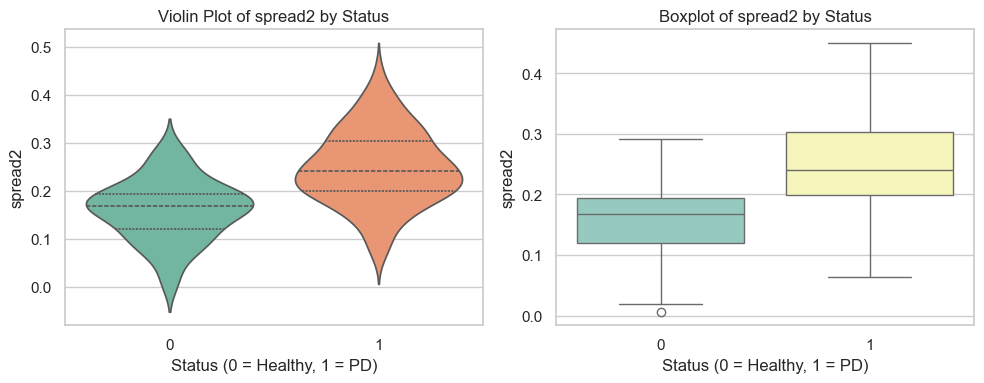

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


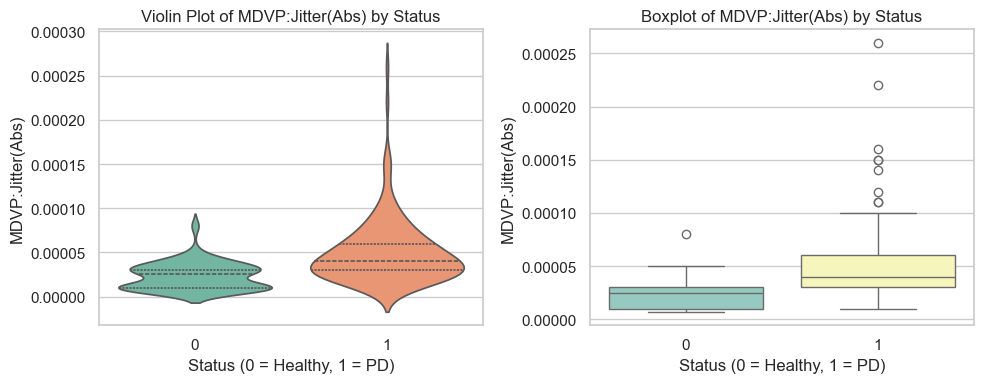

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


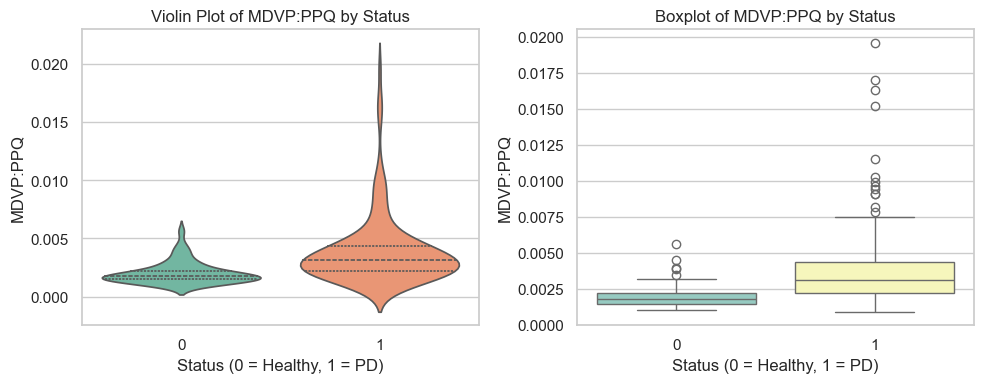

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3847362985.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="status", y=col, palette="Set3")


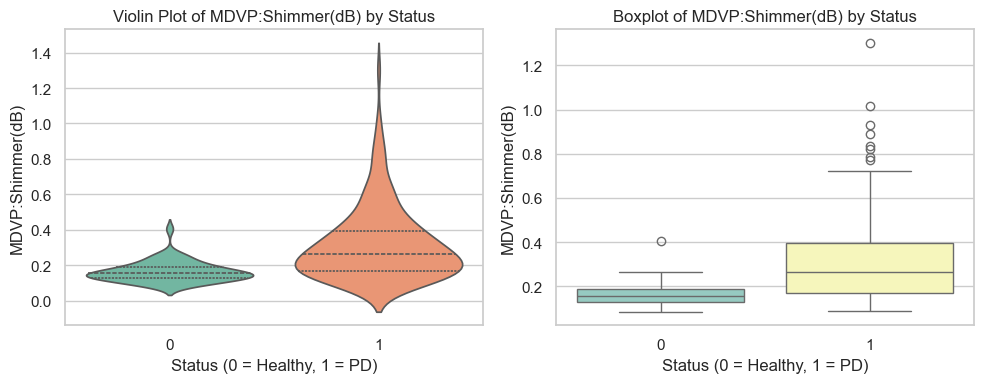

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = [
    "PPE",
    "spread1",
    "MDVP:APQ",
    "spread2",
    "MDVP:Jitter(Abs)",
    "MDVP:PPQ",
    "MDVP:Shimmer(dB)"
]

for col in top_features:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.violinplot(data=df, x="status", y=col, palette="Set2", inner="quartile")
    plt.title(f"Violin Plot of {col} by Status")
    plt.xlabel("Status (0 = Healthy, 1 = PD)")
    
    plt.subplot(1,2,2)
    sns.boxplot(data=df, x="status", y=col, palette="Set3")
    plt.title(f"Boxplot of {col} by Status")
    plt.xlabel("Status (0 = Healthy, 1 = PD)")
    
    plt.tight_layout()
    plt.show()


In [19]:
from scipy.stats import shapiro, pearsonr, spearmanr
import pandas as pd
import numpy as np

results_reg = []

numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in ["HNR", "status"]]

for col in feature_cols:
    x = df[col]
    y = df["HNR"]
    
    # Normality tests
    p_norm_x = shapiro(x)[1]
    p_norm_y = shapiro(y)[1]
    
    normal_x = p_norm_x > 0.05
    normal_y = p_norm_y > 0.05
    
    # Choose correlation test
    if normal_x and normal_y:
        test_used = "Pearson correlation"
        stat, p_value = pearsonr(x, y)
    else:
        test_used = "Spearman correlation"
        stat, p_value = spearmanr(x, y)
    results_reg.append({
        "feature": col,
        "normal_x_p": p_norm_x,
        "normal_y_p": p_norm_y,
        "both_normal": normal_x and normal_y,
        "test_used": test_used,
        "correlation_coef": stat,
        "p_value": p_value
    })

reg_table = pd.DataFrame(results_reg)
reg_table
    

,feature,normal_x_p,normal_y_p,both_normal,test_used,correlation_coef,p_value
0,MDVP:Fo(Hz),1.733784e-07,0.000643,False,Spearman correlation,0.056720,4.309307e-01
1,MDVP:Fhi(Hz),9.296040e-18,0.000643,False,Spearman correlation,-0.021590,7.644983e-01
2,MDVP:Flo(Hz),2.274372e-12,0.000643,False,Spearman correlation,0.257889,2.728154e-04
3,MDVP:Jitter(%),6.428095e-19,0.000643,False,Spearman correlation,-0.731674,5.892387e-34
4,MDVP:Jitter(Abs),2.566381e-16,0.000643,False,Spearman correlation,-0.623537,2.123663e-22
5,MDVP:RAP,6.997147e-20,0.000643,False,Spearman correlation,-0.754143,4.291479e-37
6,MDVP:PPQ,5.374313e-19,0.000643,False,Spearman correlation,-0.765617,7.877253e-39
7,Jitter:DDP,6.938482e-20,0.000643,False,Spearman correlation,-0.754015,4.481982e-37
8,MDVP:Shimmer,1.487493e-13,0.000643,False,Spearman correlation,-0.866451,3.958134e-60
9,MDVP:Shimmer(dB),5.645832e-15,0.000643,False,Spearman correlation,-0.865360,8.211954e-60


/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/3961693514.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


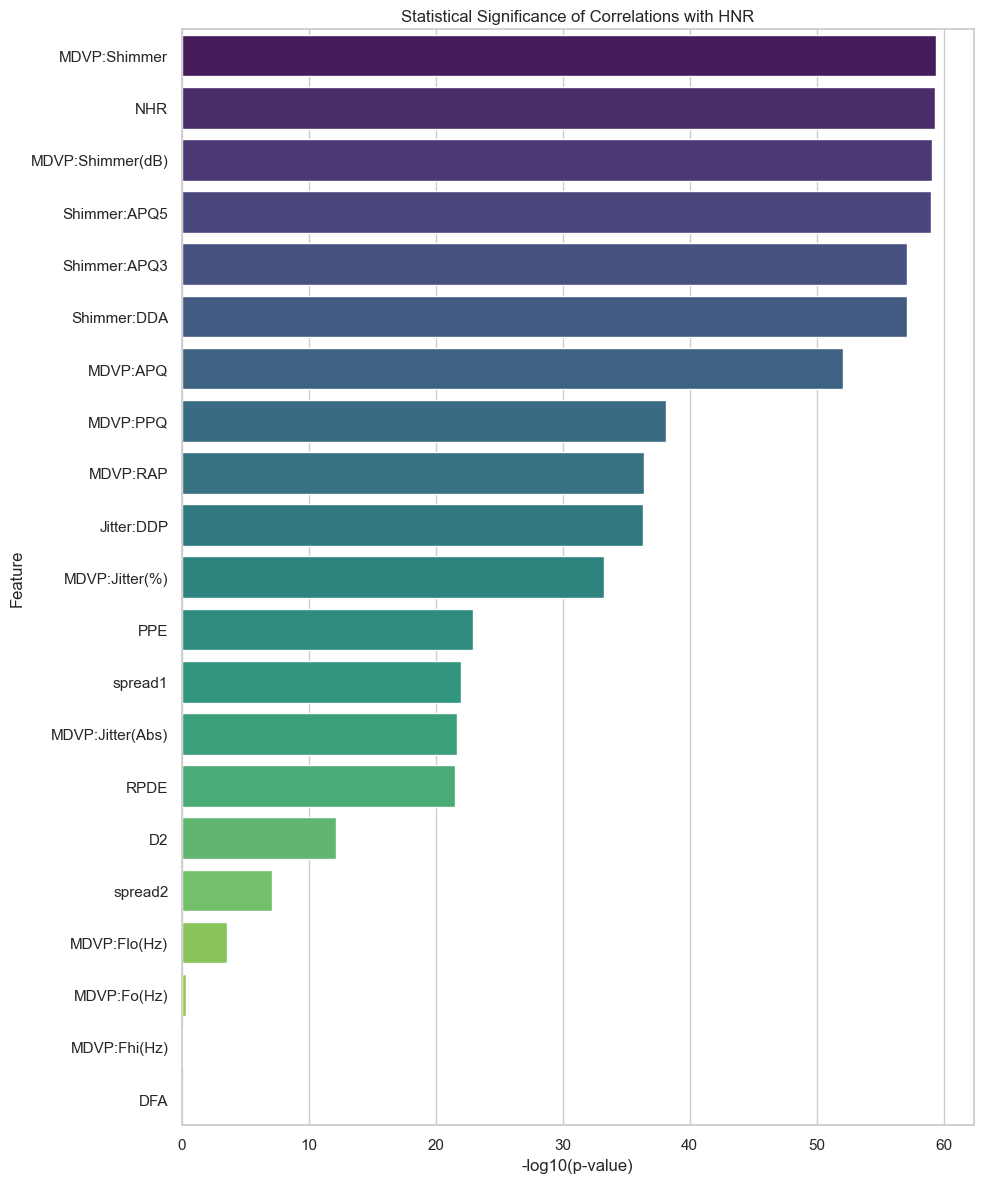

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))

plot_df_reg = reg_table.sort_values("p_value")

sns.barplot(
    x = -np.log10(plot_df_reg["p_value"]),
    y = plot_df_reg["feature"],
    palette="viridis"
)

plt.xlabel("-log10(p-value)")
plt.ylabel("Feature")
plt.title("Statistical Significance of Correlations with HNR")
plt.tight_layout()
plt.show()

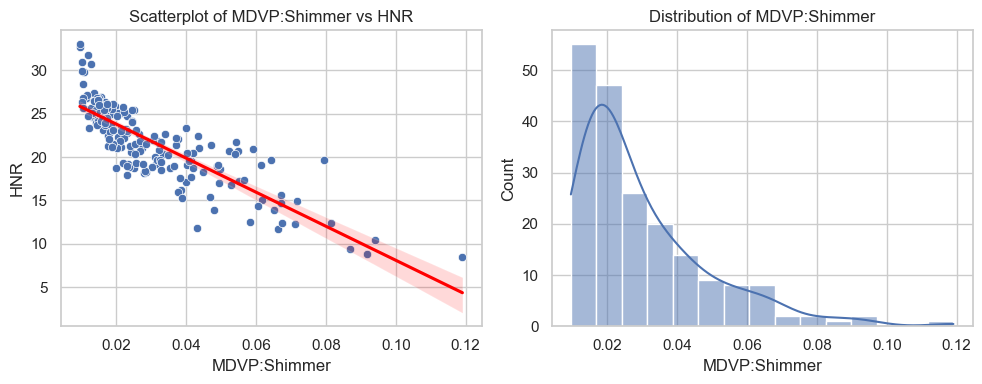

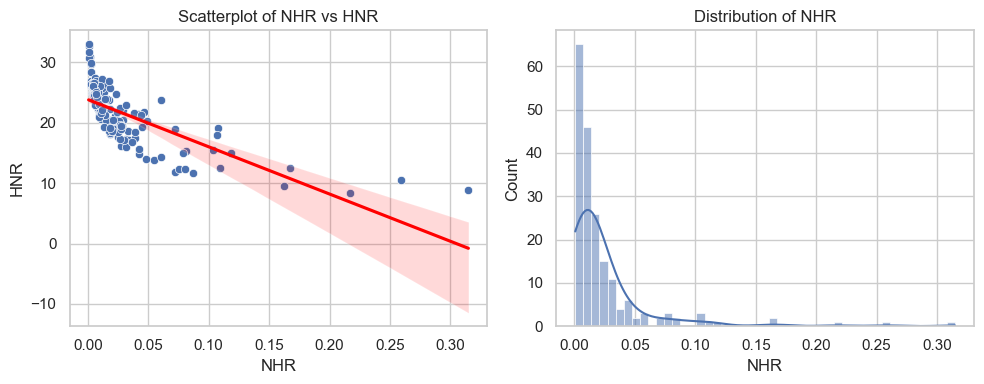

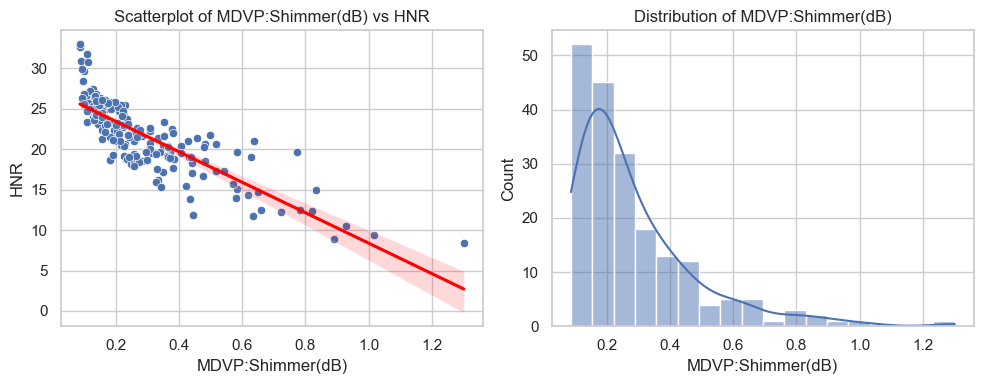

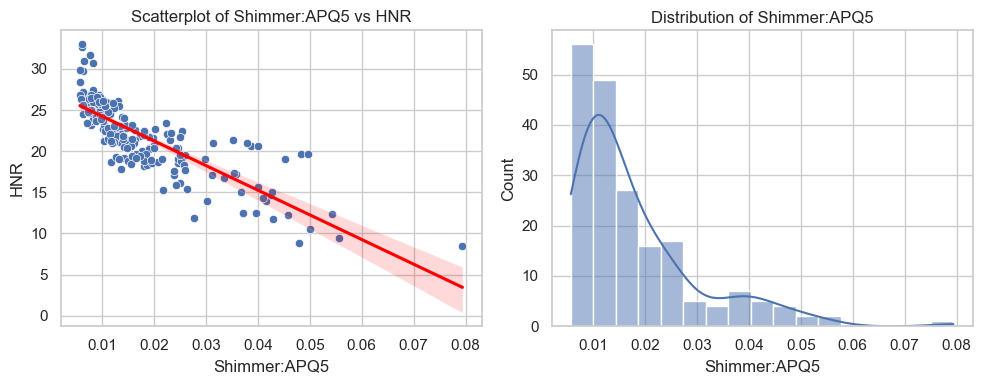

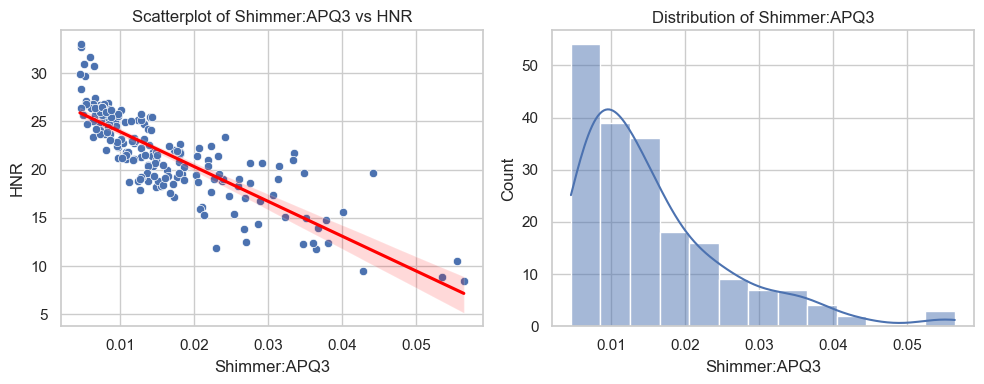

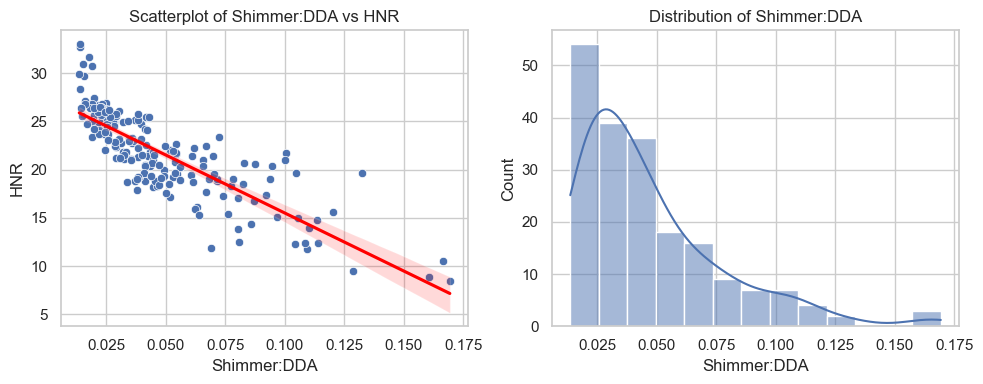

In [21]:
top_features_reg = [
    "MDVP:Shimmer",
    "NHR",
    "MDVP:Shimmer(dB)",
    "Shimmer:APQ5",
    "Shimmer:APQ3",
    "Shimmer:DDA"
]
for col in top_features_reg:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.scatterplot(x=df[col], y=df["HNR"])
    sns.regplot(x=df[col], y=df["HNR"], scatter=False, color="red")
    plt.title(f"Scatterplot of {col} vs HNR")
    plt.xlabel(col)
    plt.ylabel("HNR")
    
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    
    plt.tight_layout()
    plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=["status",  "name"])
y = df["status"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

rf_clf.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance


PPE                 0.123254
spread1             0.119375
Shimmer:APQ5        0.069105
MDVP:APQ            0.062387
spread2             0.051802
MDVP:Shimmer        0.050615
MDVP:RAP            0.047720
Jitter:DDP          0.042574
D2                  0.042525
MDVP:Fo(Hz)         0.041930
MDVP:Fhi(Hz)        0.041735
NHR                 0.041341
Shimmer:DDA         0.036069
Shimmer:APQ3        0.034917
MDVP:Flo(Hz)        0.030244
MDVP:Shimmer(dB)    0.028737
MDVP:PPQ            0.026747
RPDE                0.026259
DFA                 0.024924
MDVP:Jitter(%)      0.023531
HNR                 0.020353
MDVP:Jitter(Abs)    0.013856
dtype: float64

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/614202738.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="viridis")


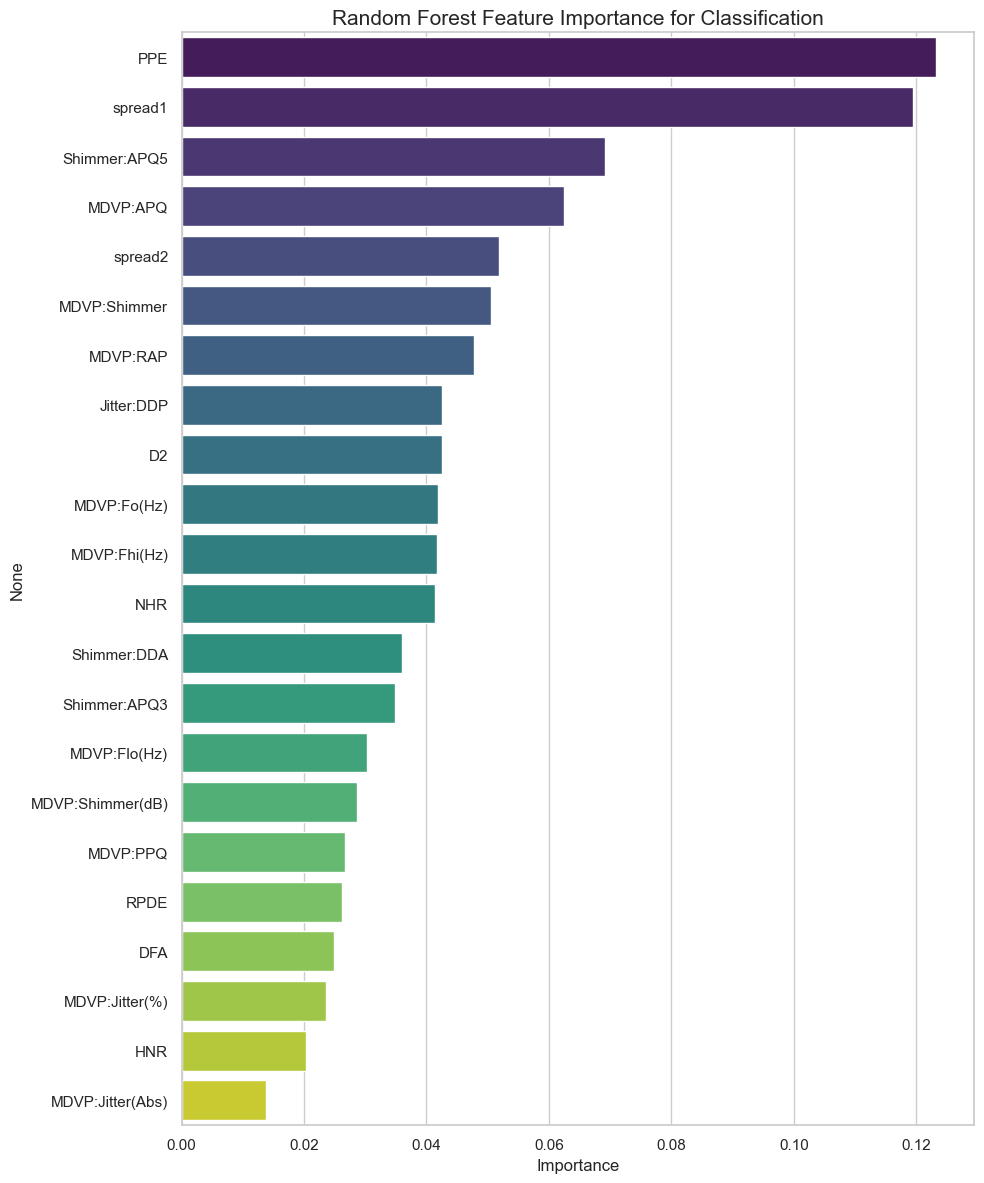

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette="viridis")
plt.title("Random Forest Feature Importance for Classification", fontsize=15)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression

lasso_clf = LogisticRegression(
    penalty="l1", 
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

lasso_clf.fit(X_scaled, y)

lasso_coef = pd.Series(
    lasso_clf.coef_[0],
    index=X.columns
).sort_values(ascending=False)

lasso_coef

spread1             1.450209
MDVP:APQ            0.994594
D2                  0.544169
PPE                 0.409627
spread2             0.394056
DFA                 0.163026
HNR                 0.025908
Shimmer:APQ3        0.000000
Shimmer:DDA         0.000000
Shimmer:APQ5        0.000000
MDVP:Shimmer(dB)    0.000000
MDVP:Shimmer        0.000000
Jitter:DDP          0.000000
MDVP:PPQ            0.000000
MDVP:RAP            0.000000
MDVP:Jitter(Abs)    0.000000
NHR                -0.000831
MDVP:Flo(Hz)       -0.046775
MDVP:Fo(Hz)        -0.183144
MDVP:Fhi(Hz)       -0.221363
RPDE               -0.356880
MDVP:Jitter(%)     -0.364566
dtype: float64

In [27]:
from sklearn.feature_selection import RFE

rfe_selector = RFE(
    estimator=LogisticRegression(solver="liblinear"),
    n_features_to_select=10
)

rfe_selector.fit(X_scaled, y)

rfe_selected = pd.Series(
    rfe_selector.support_, 
    index=X.columns
)

rfe_selected_features = rfe_selected[rfe_selected == True].index.tolist()
rfe_selected_features

['MDVP:Fo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'Jitter:DDP',
 'MDVP:APQ',
 'NHR',
 'spread1',
 'D2',
 'PPE']

In [28]:
feature_selection_results = pd.DataFrame({
    "RF_Importance": rf_importance,
    "LASSO_Coefficient": lasso_coef,
    "RFE_Selected": rfe_selected
})

feature_selection_results

,RF_Importance,LASSO_Coefficient,RFE_Selected
D2,0.042525,0.544169,True
DFA,0.024924,0.163026,False
HNR,0.020353,0.025908,False
Jitter:DDP,0.042574,0.000000,True
MDVP:APQ,0.062387,0.994594,True
MDVP:Fhi(Hz),0.041735,-0.221363,False
MDVP:Flo(Hz),0.030244,-0.046775,False
MDVP:Fo(Hz),0.041930,-0.183144,True
MDVP:Jitter(%),0.023531,-0.364566,True
MDVP:Jitter(Abs),0.013856,0.000000,True


In [29]:
final_features_classification = sorted(
    set(rf_importance.head(10).index) |
    set(lasso_coef[lasso_coef != 0].index) |
    set(rfe_selected_features)
)

final_features_classification

['D2',
 'DFA',
 'HNR',
 'Jitter:DDP',
 'MDVP:APQ',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Fo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'MDVP:Shimmer',
 'NHR',
 'PPE',
 'RPDE',
 'Shimmer:APQ5',
 'spread1',
 'spread2']

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=["HNR","NHR", "status", "name"])
y = df["HNR"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_reg.fit(X_train, y_train)

rf_importance_reg = pd.Series(
    rf_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance_reg

MDVP:Shimmer(dB)    0.361977
Shimmer:APQ5        0.156538
MDVP:APQ            0.120963
D2                  0.061114
MDVP:Shimmer        0.052699
MDVP:PPQ            0.043093
Shimmer:APQ3        0.031084
Shimmer:DDA         0.030000
Jitter:DDP          0.018825
MDVP:Jitter(%)      0.018575
MDVP:RAP            0.017098
RPDE                0.016516
DFA                 0.015734
MDVP:Flo(Hz)        0.012053
PPE                 0.011402
spread1             0.010167
MDVP:Fo(Hz)         0.007443
spread2             0.006797
MDVP:Fhi(Hz)        0.005289
MDVP:Jitter(Abs)    0.002633
dtype: float64

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/901921036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance_reg.values, y=rf_importance_reg.index, palette="viridis")


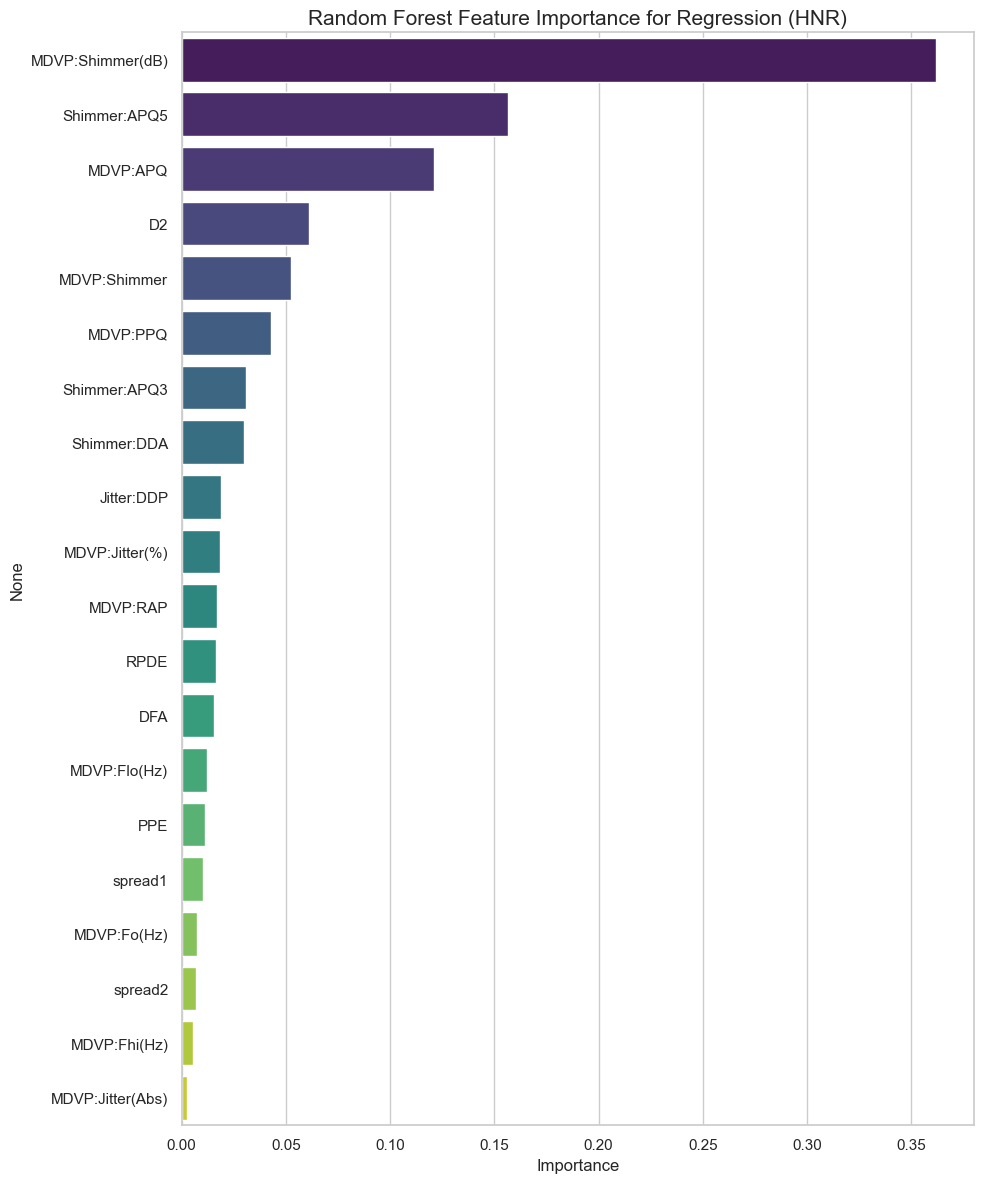

In [32]:
plt.figure(figsize=(10,12))
sns.barplot(x=rf_importance_reg.values, y=rf_importance_reg.index, palette="viridis")
plt.title("Random Forest Feature Importance for Regression (HNR)", fontsize=15)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso_reg.fit(X_scaled, y)

lasso_coef_reg = pd.Series(
    lasso_reg.coef_,
    index=X.columns
).sort_values(ascending=False)

lasso_coef_reg

MDVP:Jitter(Abs)    1.309627
MDVP:APQ            1.041583
spread2             0.689582
MDVP:Fhi(Hz)        0.173727
spread1             0.162075
MDVP:Flo(Hz)        0.146300
MDVP:RAP           -0.000000
Jitter:DDP         -0.000000
MDVP:Shimmer        0.000000
DFA                -0.095207
MDVP:Fo(Hz)        -0.200277
Shimmer:APQ5       -0.455271
MDVP:Shimmer(dB)   -0.479343
PPE                -0.502160
Shimmer:DDA        -0.511555
MDVP:Jitter(%)     -1.055907
MDVP:PPQ           -1.105020
Shimmer:APQ3       -1.166414
D2                 -1.233977
RPDE               -1.693127
dtype: float64

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/2123259102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lasso_nonzero_reg.values, y=lasso_nonzero_reg.index, palette="magma")


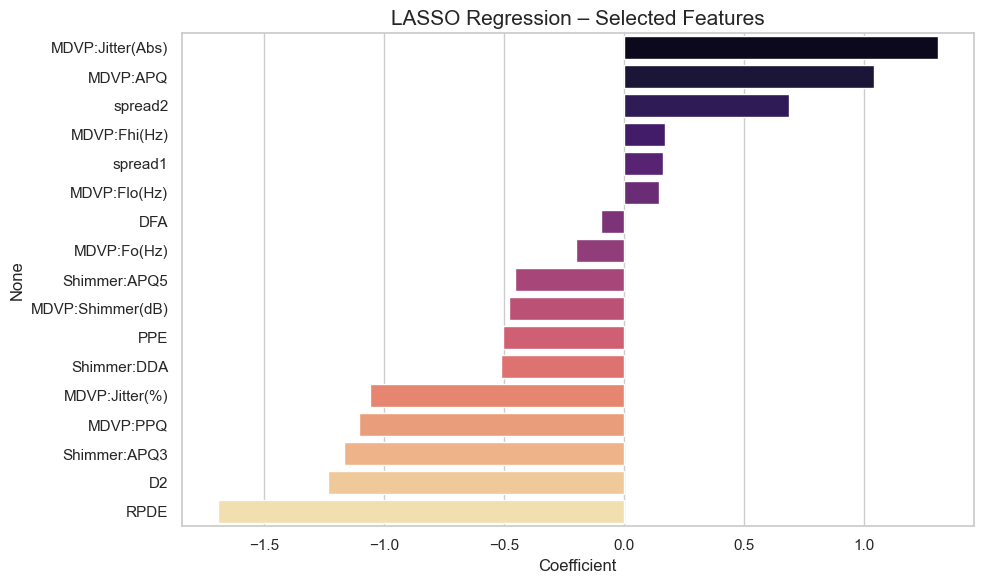

In [34]:
lasso_nonzero_reg = lasso_coef_reg[lasso_coef_reg != 0]

plt.figure(figsize=(10,6))
sns.barplot(x=lasso_nonzero_reg.values, y=lasso_nonzero_reg.index, palette="magma")
plt.title("LASSO Regression – Selected Features", fontsize=15)
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso_reg.fit(X_scaled, y)

lasso_coef_reg = pd.Series(
    lasso_reg.coef_,
    index=X.columns
).sort_values(ascending=False)

lasso_coef_reg


MDVP:Jitter(Abs)    1.309627
MDVP:APQ            1.041583
spread2             0.689582
MDVP:Fhi(Hz)        0.173727
spread1             0.162075
MDVP:Flo(Hz)        0.146300
MDVP:RAP           -0.000000
Jitter:DDP         -0.000000
MDVP:Shimmer        0.000000
DFA                -0.095207
MDVP:Fo(Hz)        -0.200277
Shimmer:APQ5       -0.455271
MDVP:Shimmer(dB)   -0.479343
PPE                -0.502160
Shimmer:DDA        -0.511555
MDVP:Jitter(%)     -1.055907
MDVP:PPQ           -1.105020
Shimmer:APQ3       -1.166414
D2                 -1.233977
RPDE               -1.693127
dtype: float64

/var/folders/9p/sf1wx0t51lbgd9vn4nz_xsk40000gn/T/ipykernel_8719/2123259102.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lasso_nonzero_reg.values, y=lasso_nonzero_reg.index, palette="magma")


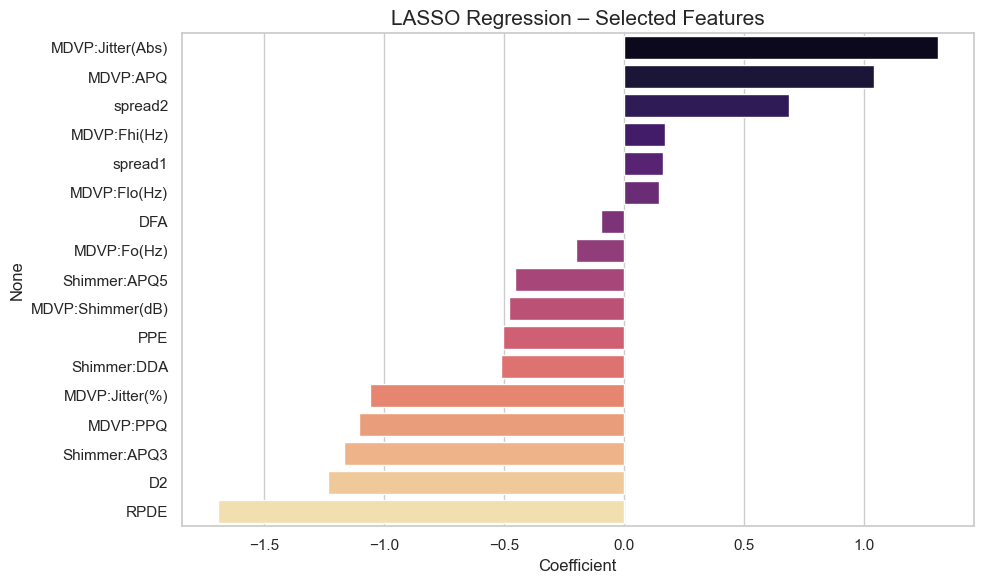

In [36]:
lasso_nonzero_reg = lasso_coef_reg[lasso_coef_reg != 0]

plt.figure(figsize=(10,6))
sns.barplot(x=lasso_nonzero_reg.values, y=lasso_nonzero_reg.index, palette="magma")
plt.title("LASSO Regression – Selected Features", fontsize=15)
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

In [37]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

rfe_selector_reg = RFE(
    estimator=LinearRegression(),
    n_features_to_select=10
)

rfe_selector_reg.fit(X_scaled, y)

rfe_selected_reg = pd.Series(
    rfe_selector_reg.support_,
    index=X.columns
)

rfe_selected_features_reg = rfe_selected_reg[rfe_selected_reg == True].index.tolist()
rfe_selected_features_reg

['MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:RAP',
 'Jitter:DDP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:DDA',
 'RPDE']

In [38]:
feature_selection_reg = pd.DataFrame({
    "RF_Importance": rf_importance_reg,
    "LASSO_Coefficient": lasso_coef_reg,
    "RFE_Selected": rfe_selected_reg
})

feature_selection_reg

,RF_Importance,LASSO_Coefficient,RFE_Selected
D2,0.061114,-1.233977,False
DFA,0.015734,-0.095207,False
Jitter:DDP,0.018825,-0.000000,True
MDVP:APQ,0.120963,1.041583,False
MDVP:Fhi(Hz),0.005289,0.173727,False
MDVP:Flo(Hz),0.012053,0.146300,False
MDVP:Fo(Hz),0.007443,-0.200277,False
MDVP:Jitter(%),0.018575,-1.055907,True
MDVP:Jitter(Abs),0.002633,1.309627,True
MDVP:PPQ,0.043093,-1.105020,False


In [39]:
final_features_regression = sorted(
    set(rf_importance_reg.head(10).index) |
    set(lasso_nonzero_reg.index) |
    set(rfe_selected_features_reg)
)

final_features_regression

['D2',
 'DFA',
 'Jitter:DDP',
 'MDVP:APQ',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Fo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Jitter(Abs)',
 'MDVP:PPQ',
 'MDVP:RAP',
 'MDVP:Shimmer',
 'MDVP:Shimmer(dB)',
 'PPE',
 'RPDE',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:DDA',
 'spread1',
 'spread2']